In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")

from analysis.load_run_data import load_run_data
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from rastermap import Rastermap
import numpy as np
from itertools import combinations
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from tqdm import trange
import pickle
from tqdm import tqdm
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score

from analysis.utils import extract_variables

In [3]:
data = load_run_data(
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps_logs/initial_conditions')

Found 9 episode directories in /home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps_logs/initial_conditions
Loaded 9 episodes
Loaded 9 planning episodes


In [4]:
exp_vars = extract_variables(
    data,
    variables=['latent_states', 'observations', 'actions', 'rewards'],
    n_steps=500)

In [5]:
for var in exp_vars:
    print(f"{var}: {exp_vars[var][0].shape}")

latent_states: (500, 512)
observations: (500, 5)
actions: (500, 1)
rewards: (500, 1)


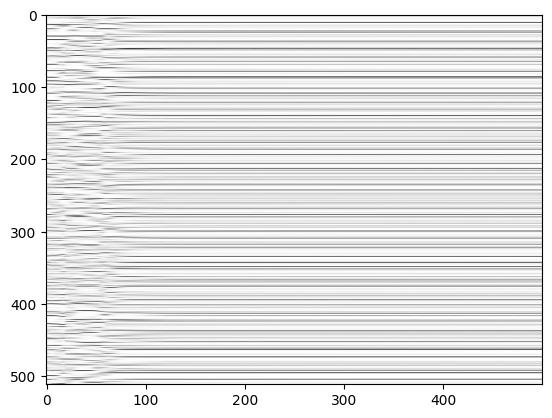

In [6]:
plt.imshow(exp_vars['latent_states'][8].T[:, :500],
           aspect='auto',
           cmap='gray_r')

## Linear decoding


In [7]:
def make_lagged_pairs_for_episode(x_ep, y_ep, lag):
    """Build (X, Y) pairs within one episode for given lag."""
    T = len(x_ep)
    if lag >= 0:
        t_src = np.arange(0, T - lag)
        t_tgt = t_src + lag

    elif lag < 0:
        # Predict the past: (z_t, y_{t+lag}) = (z_t, y_{t-|lag|})
        shift = abs(lag)
        t_src = np.arange(shift, T)
        t_tgt = np.arange(0, T - shift)

    return x_ep[t_src], y_ep[t_tgt]


def bootstrap_ci(vals, alpha=0.05, n_boot=1000):
    rng = np.random.RandomState(0)
    boot_means = np.zeros(n_boot)
    for b in range(n_boot):
        resampled = rng.choice(vals, size=len(vals), replace=True)
        boot_means[b] = np.mean(resampled)

    lower = np.percentile(boot_means, alpha)
    upper = np.percentile(boot_means, 100 - alpha)
    return (lower, upper)

In [8]:
def evaluate_lags_leave_k_out(x_eps,
                              y_eps,
                              lags,
                              k_holdout=1,
                              model='linear_regression',
                              max_combinations=None,
                              add_bootstrap_ci=False,
                              alpha=0.05,
                              n_bootstrap=1000):
    """
    Evaluate R² vs lag with leave-k-episodes-out CV.

    Args:
        x_eps: list of [N_eps_i, L] arrays
        obs_eps: list of [N_eps_i, D] arrays
        y_eps: iterable of integer lags
        k_holdout: number of episodes to leave out per fold
        max_combinations: optional limit on number of folds (for large episode counts)

    Returns:
        r2_mean, r2_std, r2_by_lag: dicts keyed by lag
    """
    n_eps = len(x_eps)
    assert n_eps > k_holdout, "k_holdout must be smaller than number of episodes"

    # Enumerate folds (all combinations or sampled subset)
    all_combos = list(combinations(range(n_eps), k_holdout))
    if max_combinations is not None and len(all_combos) > max_combinations:
        np.random.seed(0)
        all_combos = list(
            np.random.choice(len(all_combos), max_combinations, replace=False))

    r2_by_lag = {lag: [] for lag in lags}
    model_by_lag = {lag: [] for lag in lags}

    for test_idxs in tqdm(all_combos):
        test_idxs = np.atleast_1d(test_idxs)
        train_idxs = [i for i in range(n_eps) if i not in test_idxs]

        for lag in lags:
            # Collect training pairs
            X_train_list, Y_train_list = [], []
            for i in train_idxs:
                X_i, Y_i = make_lagged_pairs_for_episode(
                    x_eps[i], y_eps[i], lag)
                X_train_list.append(X_i)
                Y_train_list.append(Y_i)

            X_train = np.concatenate(X_train_list, axis=0)
            Y_train = np.concatenate(Y_train_list, axis=0)

            if model == 'linear_regression':
                model_to_fit = LinearRegression()
            elif model == 'lasso':
                model_to_fit = Lasso(alpha=0.001)
            else:
                raise ValueError(f"Model {model} not supported")

            # Fit model on training set
            model_to_fit = model_to_fit.fit(X_train, Y_train)

            # Evaluate on each held-out episode
            fold_r2s = []
            for j in test_idxs:
                X_te, Y_te = make_lagged_pairs_for_episode(
                    x_eps[j], y_eps[j], lag)
                Y_pred = model_to_fit.predict(X_te)
                r2 = r2_score(Y_te, Y_pred, multioutput='variance_weighted')
                fold_r2s.append(r2)

            r2_by_lag[lag].append(
                np.mean(fold_r2s))  # mean R² over held-out eps in this fold

            model_by_lag[lag] = model_to_fit

    # Aggregate mean and std over folds
    r2_mean = {
        lag: np.mean(vals) if len(vals) else np.nan
        for lag, vals in r2_by_lag.items()
    }
    r2_std = {
        lag: np.std(vals, ddof=1) if len(vals) > 1 else np.nan
        for lag, vals in r2_by_lag.items()
    }

    results = {
        'r2_mean': r2_mean,
        'r2_std': r2_std,
        'r2_by_lag': r2_by_lag,
        'model_by_lag': model_by_lag,
    }

    if add_bootstrap_ci:
        r2_ci = {
            lag:
                bootstrap_ci(vals, alpha=alpha, n_boot=n_bootstrap)
                if len(vals) else np.nan for lag, vals in r2_by_lag.items()
        }
        results['r2_ci'] = r2_ci

    return results

In [10]:
combinations_vars = [
    ('latent_states', 'observations'),
    ('latent_states', 'rewards'),
    ('latent_states', 'actions'),
    ('observations', 'observations'),
    ('rewards', 'rewards'),
    ('actions', 'actions'),
]

models_to_fit = ['linear_regression', 'lasso']

results_decoding = {}

for model in models_to_fit:
    for x_var, y_var in combinations_vars:
        print(f"Decoding {x_var} -> {y_var} with {model}")
        results_decoding[f'{x_var}-{y_var}'] = evaluate_lags_leave_k_out(
            exp_vars[x_var],
            exp_vars[y_var],
            model=model,
            lags=np.arange(-100, 101),
            k_holdout=1,
            add_bootstrap_ci=True)

    # Save results_decoding to pickle file
    with open(f'results_decoding_{model}.pkl', 'wb') as f:
        pickle.dump(results_decoding, f)

Decoding latent_states -> observations with linear_regression


  0%|          | 0/9 [00:00<?, ?it/s]

100%|██████████| 9/9 [02:10<00:00, 14.49s/it]


Decoding latent_states -> rewards with linear_regression


100%|██████████| 9/9 [02:09<00:00, 14.40s/it]


...

100%|██████████| 9/9 [00:03<00:00,  2.41it/s]


Decoding rewards -> rewards with lasso


100%|██████████| 9/9 [00:02<00:00,  4.48it/s]


Decoding actions -> actions with lasso


100%|██████████| 9/9 [00:01<00:00,  4.54it/s]


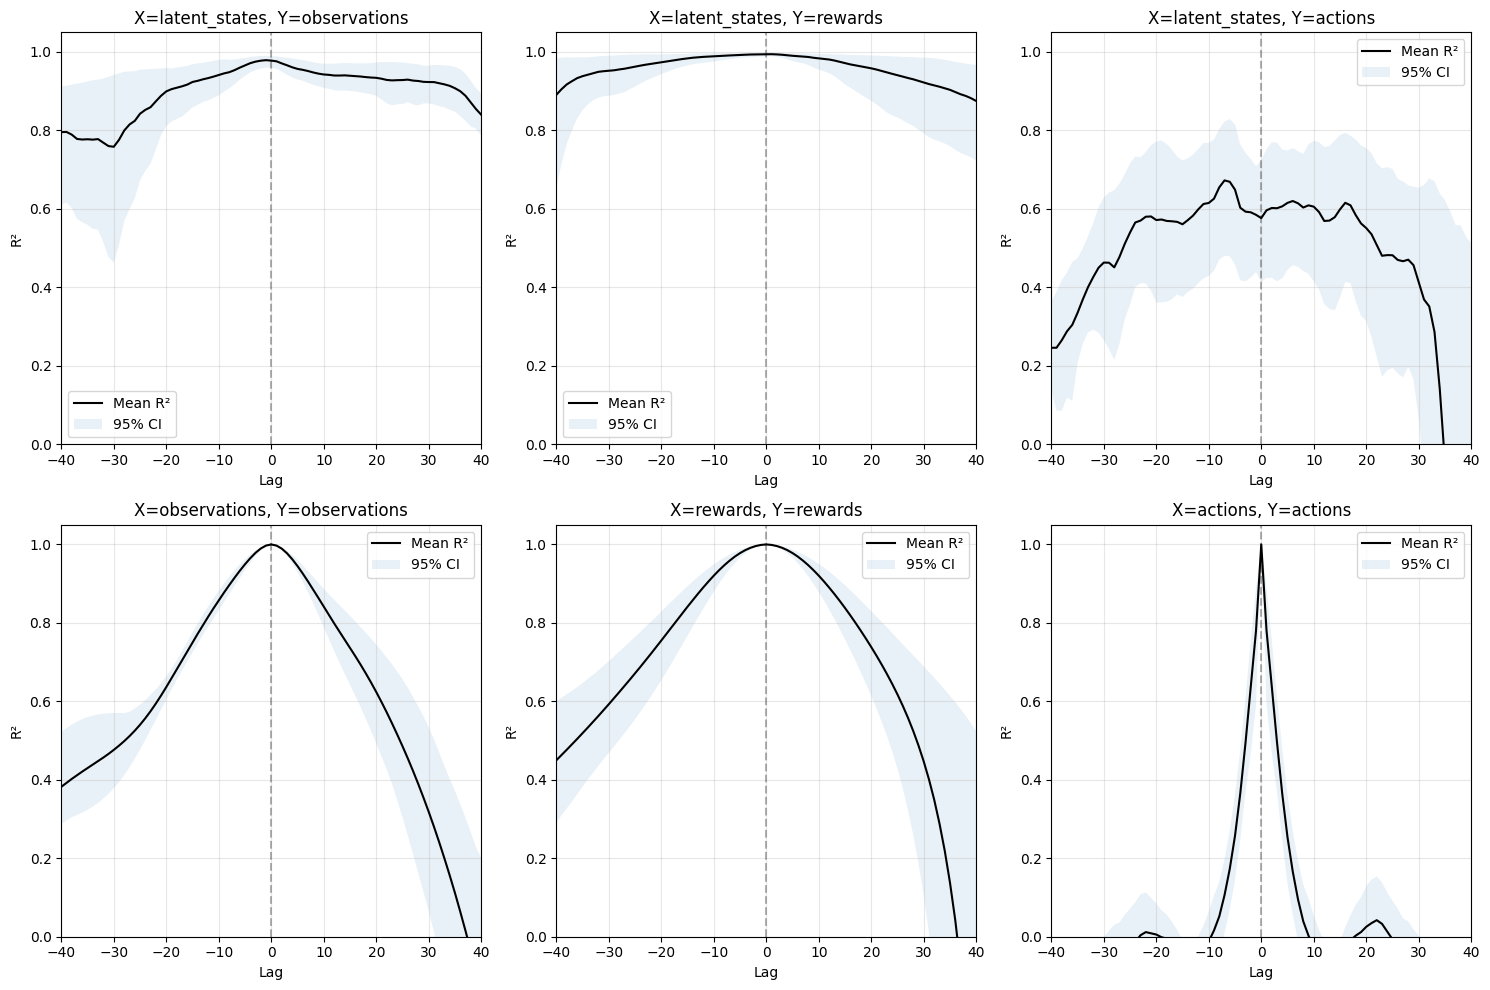

In [26]:
# Load the results from pickle file
with open('/home/hgf_hmgu/hgf_gib4562/tdmpc2/results_decoding_lasso.pkl',
          'rb') as f:
    results_decoding_lasso = pickle.load(f)

# Plot R2 means with bootstrapped confidence intervals for each combination
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (key, results) in enumerate(results_decoding_lasso.items()):
    ax = axes[idx]

    r2_mean = results['r2_mean']
    r2_ci = results['r2_ci']

    # Extract lags and R² values from the dictionary
    lags = list(r2_mean.keys())
    means = list(r2_mean.values())

    # r2_ci is a tuple of (lower_dict, upper_dict)
    ci_lower = [r2_ci[lag][0] for lag in lags]
    ci_upper = [r2_ci[lag][1] for lag in lags]

    ax.plot(lags, means, label='Mean R²', color='black')
    ax.fill_between(lags, ci_lower, ci_upper, alpha=0.1, label='95% CI')
    ax.set_xlabel('Lag')
    ax.set_ylabel('R²')
    title = key.split('-')
    ax.set_title(f'X={title[0]}, Y={title[1]}')
    ax.grid(True, alpha=0.3)
    #ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.set_xlim(-40, 40)

plt.tight_layout()
plt.show()


In [ ]:
results_decoding_lasso['latent_states-observations']['model_by_lag'][3]

(5, 512)

{'r2_mean': {-30: -0.06009855535295275,
  -29: -0.05844372510910034,
  -28: -0.053637087552083865,
  -27: -0.052538279030058116,
  -26: -0.040646903320319124,
  -25: -0.02823977337943183,
  -24: -0.013440960397322973,
  -23: 0.003744204839070638,
  -22: 0.011781315836641524,
  -21: 0.00872496763865153,
  -20: 0.005602606468730503,
  -19: -0.0012969838248358832,
  -18: -0.004858547200759252,
  -17: -0.011500086842311753,
  -16: -0.01905418092954076,
  -15: -0.029645589490731556,
  -14: -0.033171084295544356,
  -13: -0.03777311990658442,
  -12: -0.036642372608184814,
  -11: -0.028461363063090377,
  -10: -0.012080662780337863,
  -9: 0.01619839006000095,
  -8: 0.05171669191784329,
  -7: 0.10582983493804932,
  -6: 0.17312263780170017,
  -5: 0.25740961564911735,
  -4: 0.3649015426635742,
  -3: 0.49448563324080574,
  -2: 0.6364701059129503,
  -1: 0.7799857921070523,
  0: 0.9999234477678934,
  1: 0.7810415559344821,
  2: 0.6381248831748962,
  3: 0.49535535441504586,
  4: 0.3639330085780885,
  

In [46]:
key

'actions_actions'

## per latent LR

In [29]:
import numpy as np
from itertools import combinations
from tqdm import tqdm
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score


In [ ]:
def per_latent_leave_k_out(
    z_eps,
    y_eps,
    k_holdout=1,
    max_combinations=None,
    model='linear_regression',
    n_boot=1000,
    ci=95,
    random_state=0,
):
    """
    Leave-k-episodes-out CV for per-latent multivariate regression probes.

    Args:
        z_eps: list of [N_ep_i, L] latent arrays
        y_eps: list of [N_ep_i, D] target arrays
        k_holdout: number of episodes to leave out per fold
        alpha: ridge regularization strength
        max_combinations: optional limit on number of folds (for large episode counts)
        n_boot: number of bootstrap resamples for CIs
        ci: confidence interval (%)
        random_state: RNG seed

    Returns:
        r2_mean : (L, D) mean R² across folds
        r2_std  : (L, D) std R² across folds
        r2_ci   : (L, D, 2) lower/upper bootstrap CIs
        r2_by_fold : dict[(fold_idx)] -> (L, D) array of per-latent per-output R²s
    """
    rng = np.random.default_rng(random_state)
    n_eps = len(z_eps)
    assert n_eps > k_holdout, "k_holdout must be smaller than number of episodes"

    all_combos = list(combinations(range(n_eps), k_holdout))
    if max_combinations is not None and len(all_combos) > max_combinations:
        idxs = rng.choice(len(all_combos), size=max_combinations, replace=False)
        all_combos = [all_combos[i] for i in idxs]

    # Determine latent/output dims
    L = z_eps[0].shape[1]  # number of latent dimensions
    D = y_eps[0].shape[1]  # number of output dimensions

    # store per-fold results
    r2_by_fold = {}
    fold_idx = 0

    for test_idxs in tqdm(all_combos, desc="Folds"):
        test_idxs = np.atleast_1d(test_idxs)
        train_idxs = [i for i in range(n_eps) if i not in test_idxs]

        # concatenate training and test data
        z_train = np.concatenate([z_eps[i] for i in train_idxs], axis=0)
        y_train = np.concatenate([y_eps[i] for i in train_idxs], axis=0)

        # evaluate per-latent models on test episodes
        fold_r2 = np.full((L, D), np.nan)

        for i in range(L):
            xi = z_train[:, i:i + 1]

            if model == 'linear_regression':
                model_to_fit = LinearRegression().fit(xi, y_train)
            elif model == 'lasso':
                model_to_fit = Lasso(alpha=0.001).fit(xi, y_train)
            else:
                raise ValueError(f"Model {model} not supported")

            # collect test samples
            z_test = np.concatenate([z_eps[j][:, i:i + 1] for j in test_idxs],
                                    axis=0)
            y_test = np.concatenate([y_eps[j] for j in test_idxs], axis=0)

            y_pred = model_to_fit.predict(z_test)

            if D == 1:
                fold_r2[i, 0] = r2_score(y_test, y_pred)
            else:
                for d in range(D):
                    fold_r2[i, d] = r2_score(y_test[:, d], y_pred[:, d])

        r2_by_fold[fold_idx] = fold_r2
        fold_idx += 1

    # stack folds
    r2_stack = np.stack(list(r2_by_fold.values()), axis=0)  # (n_folds, L, D)
    r2_mean = np.nanmean(r2_stack, axis=0)
    r2_std = np.nanstd(r2_stack, axis=0, ddof=1)

    # # bootstrap CI over folds
    # print("Computing bootstrap CIs")
    # n_folds = r2_stack.shape[0]
    # alpha_p = (100 - ci) / 2
    # lower = np.full((L, D), np.nan)
    # upper = np.full((L, D), np.nan)
    # for i in range(L):
    #     for d in range(D):
    #         vals = r2_stack[:, i, d]
    #         vals = vals[~np.isnan(vals)]
    #         if len(vals) == 0:
    #             continue
    #         boot_means = np.zeros(n_boot)
    #         for b in range(n_boot):
    #             sample = rng.choice(vals, size=len(vals), replace=True)
    #             boot_means[b] = np.mean(sample)
    #         lower[i, d] = np.percentile(boot_means, alpha_p)
    #         upper[i, d] = np.percentile(boot_means, 100 - alpha_p)

    # r2_ci = np.stack([lower, upper], axis=-1)
    return r2_mean, r2_std, r2_by_fold


In [65]:
# z_eps, y_eps = list of arrays per episode

x_var = 'latent_states'
y_var = 'rewards'
r2_mean, r2_std, r2_by_fold = per_latent_leave_k_out(exp_vars[x_var],
                                                     exp_vars[y_var],
                                                     k_holdout=1,
                                                     model='lasso',
                                                     n_boot=2000)

Folds:   0%|          | 0/9 [00:00<?, ?it/s]

Folds: 100%|██████████| 9/9 [00:04<00:00,  1.85it/s]


In [ ]:
r2_by_fold[0]


(512, 1)

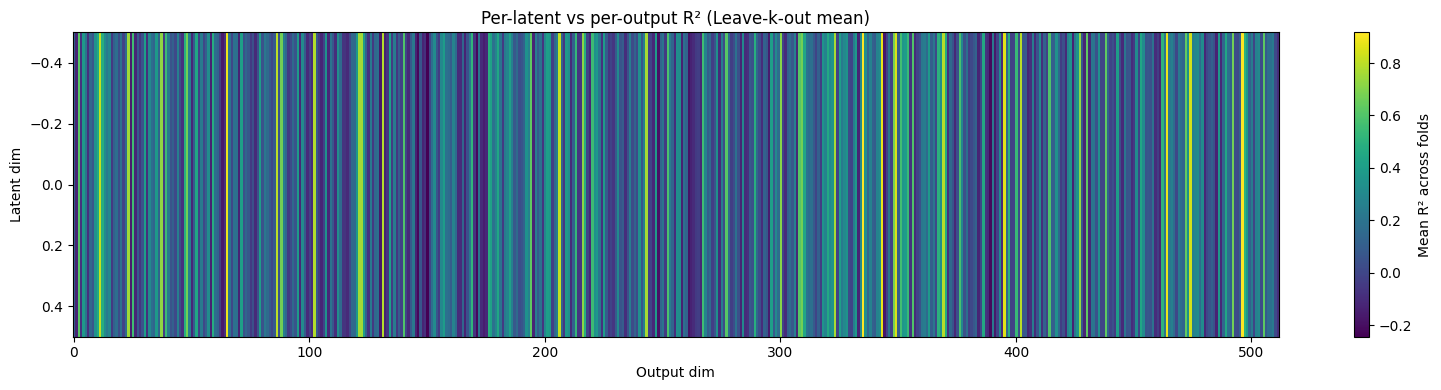

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 4))
plt.imshow(r2_mean.T, cmap='viridis', interpolation='none', aspect='auto')
plt.colorbar(label='Mean R² across folds')
plt.xlabel('Output dim')
plt.ylabel('Latent dim')
plt.title('Per-latent vs per-output R² (Leave-k-out mean)')
plt.tight_layout()
plt.show()


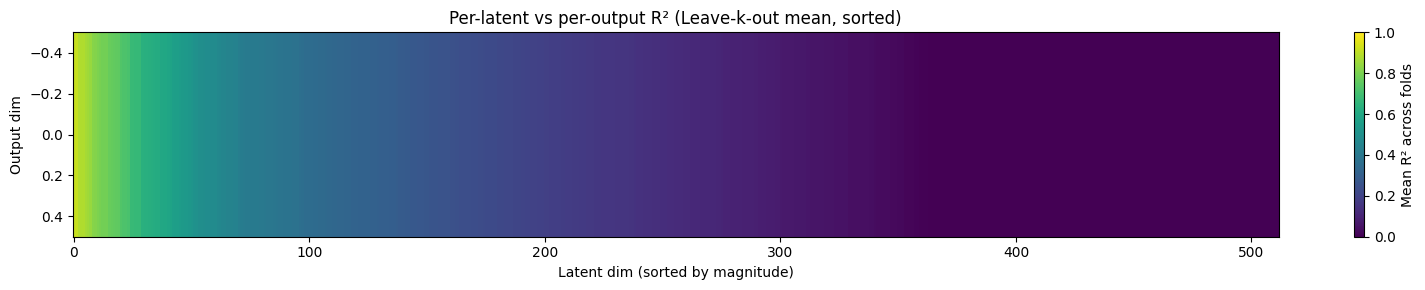

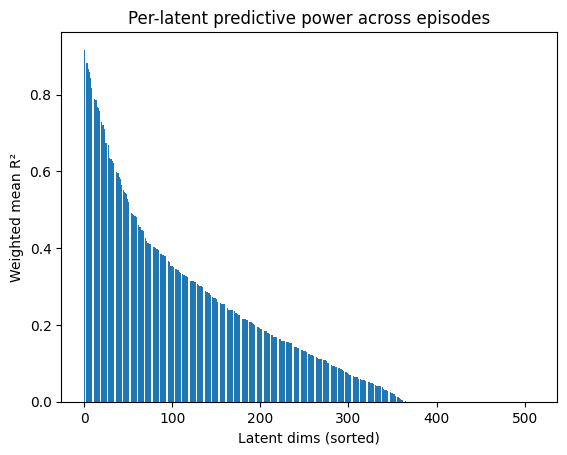

In [76]:
weights = np.var(np.concatenate(exp_vars[y_var], axis=0), axis=0)
weights = weights / np.sum(weights)
r2_weighted = (r2_mean * weights[None, :]).sum(axis=1)

order = np.argsort(r2_weighted)[::-1]
plt.bar(np.arange(len(order)), r2_weighted[order])
plt.xlabel('Latent dims (sorted)')
plt.ylabel('Weighted mean R²')
plt.title('Per-latent predictive power across episodes')
plt.show()


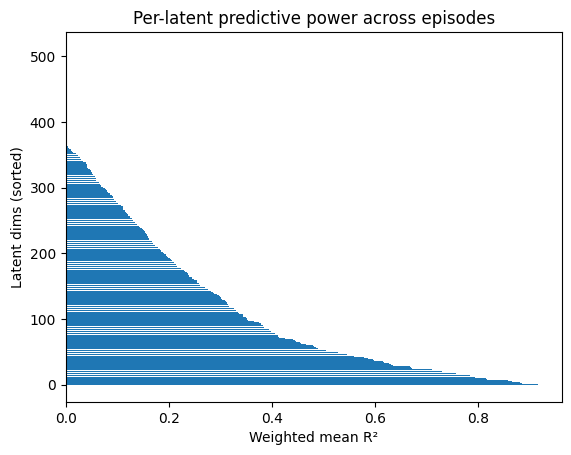

In [75]:
weights = np.var(np.concatenate(exp_vars[y_var], axis=0), axis=0)
weights = weights / np.sum(weights)
r2_weighted = (r2_mean * weights[None, :]).sum(axis=1)

order = np.argsort(r2_weighted)[::-1]
plt.barh(np.arange(len(order)), r2_weighted[order])
plt.ylabel('Latent dims (sorted)')
plt.xlabel('Weighted mean R²')
plt.title('Per-latent predictive power across episodes')
plt.show()

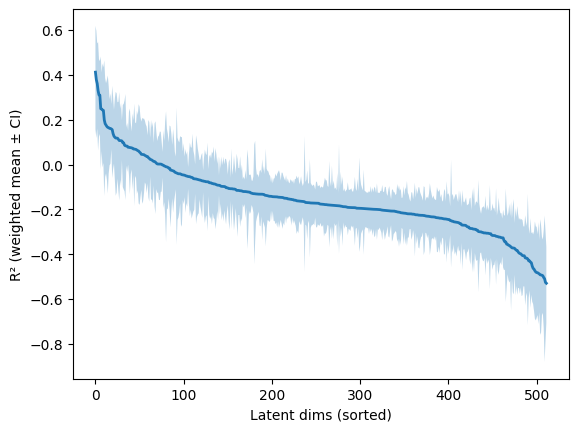

In [38]:
L = r2_mean.shape[0]
lower = (r2_ci[:, :, 0] * weights[None, :]).sum(axis=1)
upper = (r2_ci[:, :, 1] * weights[None, :]).sum(axis=1)
plt.fill_between(np.arange(L), lower[order], upper[order], alpha=0.3)
plt.plot(r2_weighted[order], lw=2)
plt.xlabel('Latent dims (sorted)')
plt.ylabel('R² (weighted mean ± CI)')
plt.show()

In [97]:
import numpy as np
from itertools import combinations
from tqdm import tqdm
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score


def get_model(model):
    if model == 'linear_regression':
        return LinearRegression()
    elif model == 'lasso':
        return Lasso(alpha=0.001)
    elif model == 'ridge':
        return Ridge(alpha=1.0)
    else:
        raise ValueError(f"Model {model} not supported")


def latent_semantics_leave_k_out(
    z_eps,
    y_eps,
    k_holdout=1,
    model='linear_regression',
    mode="joint",  # 'joint' or 'pairwise'
    r2_joint_mode='individual',  # 'individual' or 'global'
    max_combinations=None,
    add_bootstrap_ci=True,
    n_boot=1000,  # number of bootstrap resamples
    ci=95,  # confidence level (percent)
    random_state=0,
):
    """
    Leave-k-episodes-out CV for per-latent semantic regressions, with bootstrap CIs.

    Two modes:
        - 'joint':   y (D-dim) = W_i * z_i + b_i   (one multi-output model per latent)
        - 'pairwise': y_j = w_ij * z_i + b_ij      (one scalar model per latent–output pair)
    """
    assert mode in ("joint", "pairwise"), "mode must be 'joint' or 'pairwise'"

    n_eps = len(z_eps)
    assert n_eps > k_holdout, "k_holdout must be smaller than number of episodes"

    rng = np.random.default_rng(random_state)
    all_combos = list(combinations(range(n_eps), k_holdout))
    if max_combinations is not None and len(all_combos) > max_combinations:
        idxs = rng.choice(len(all_combos), size=max_combinations, replace=False)
        all_combos = [all_combos[i] for i in idxs]

    L = z_eps[0].shape[1]
    D = y_eps[0].shape[1]

    # special handling for global R² (single scalar)
    if mode == 'joint' and r2_joint_mode == 'global':
        D_out = 1
    else:
        D_out = D

    r2_by_fold = {}
    fold_idx = 0

    for test_idxs in tqdm(all_combos, desc=f"Leave-{k_holdout}-out ({mode})"):
        test_idxs = np.atleast_1d(test_idxs)
        train_idxs = [i for i in range(n_eps) if i not in test_idxs]

        # Concatenate training and test data
        z_train = np.concatenate([z_eps[i] for i in train_idxs], axis=0)
        y_train = np.concatenate([y_eps[i] for i in train_idxs], axis=0)
        z_test = np.concatenate([z_eps[j] for j in test_idxs], axis=0)
        y_test = np.concatenate([y_eps[j] for j in test_idxs], axis=0)

        fold_r2 = np.full((L, D_out), np.nan)

        if mode == "joint":
            # one multi-output regression per latent
            for i in range(L):
                xi_tr = z_train[:, i:i + 1]
                xi_te = z_test[:, i:i + 1]
                model_to_fit = get_model(model).fit(xi_tr, y_train)
                y_pred = model_to_fit.predict(xi_te)

                if r2_joint_mode == 'individual':
                    for d in range(D):
                        fold_r2[i, d] = r2_score(y_test[:, d], y_pred[:, d])
                elif r2_joint_mode == 'global':
                    fold_r2[i, 0] = r2_score(y_test,
                                             y_pred,
                                             multioutput='variance_weighted')

        elif mode == "pairwise":
            # one scalar regression per latent-output pair
            for i in range(L):
                xi_tr = z_train[:, i]
                xi_te = z_test[:, i]
                for d in range(D):
                    model_to_fit = get_model(model).fit(xi_tr.reshape(-1, 1),
                                                        y_train[:, d])
                    y_pred = model_to_fit.predict(xi_te.reshape(-1, 1))
                    fold_r2[i, d] = r2_score(y_test[:, d], y_pred)

        r2_by_fold[fold_idx] = fold_r2
        fold_idx += 1

    # stack folds → (n_folds, L, D_out)
    r2_stack = np.stack(list(r2_by_fold.values()), axis=0)
    r2_mean = np.nanmean(r2_stack, axis=0)
    r2_std = np.nanstd(r2_stack, axis=0, ddof=1)

    results = {
        'r2_mean': r2_mean,
        'r2_std': r2_std,
        'r2_by_fold': r2_by_fold,
    }

    # -----------------------------
    # Bootstrap confidence intervals
    # -----------------------------

    if add_bootstrap_ci:
        print("Computing bootstrap CIs")
        alpha_p = (100 - ci) / 2
        lower = np.full((L, D_out), np.nan)
        upper = np.full((L, D_out), np.nan)

        for i in tqdm(range(L), desc="Bootstrapping CIs"):
            for d in range(D_out):
                vals = r2_stack[:, i, d]
                vals = vals[~np.isnan(vals)]
                if len(vals) == 0:
                    continue
                boot_means = np.zeros(n_boot)
                for b in range(n_boot):
                    sample = rng.choice(vals, size=len(vals), replace=True)
                    boot_means[b] = np.mean(sample)
                lower[i, d] = np.percentile(boot_means, alpha_p)
                upper[i, d] = np.percentile(boot_means, 100 - alpha_p)

        r2_ci = np.stack([lower, upper], axis=-1)  # (L, D_out, 2)
        results['r2_ci'] = r2_ci

    return results

In [100]:
# z_eps, y_eps = list of arrays per episode

x_var = 'latent_states'
y_var = 'observations'
results = latent_semantics_leave_k_out(exp_vars[x_var],
                                       exp_vars[y_var],
                                       k_holdout=1,
                                       model='lasso',
                                       mode='pairwise',
                                       r2_joint_mode='global')

Leave-1-out (pairwise):   0%|          | 0/9 [00:00<?, ?it/s]

Leave-1-out (pairwise): 100%|██████████| 9/9 [00:22<00:00,  2.54s/it]


Computing bootstrap CIs


Bootstrapping CIs: 100%|██████████| 512/512 [00:39<00:00, 12.85it/s]


In [104]:
r2_mean = results['r2_mean']
r2_std = results['r2_std']
r2_ci = results['r2_ci']
r2_by_fold = results['r2_by_fold']


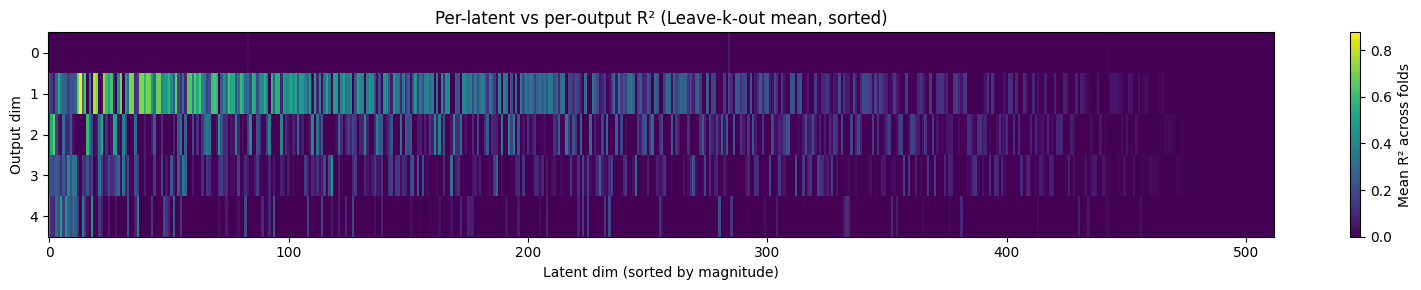

In [107]:
import matplotlib.pyplot as plt

# Sort latent dimensions by their overall magnitude

r2_mean = np.maximum(r2_mean, 0)
latent_magnitudes = np.sum(np.abs(r2_mean), axis=1)
sorted_indices = np.argsort(latent_magnitudes)[::-1]

plt.figure(figsize=(16, 3))
plt.imshow(r2_mean[sorted_indices].T,
           cmap='viridis',
           interpolation='none',
           aspect='auto',
           vmin=0,
           vmax=r2_mean.max())

plt.colorbar(label='Mean R² across folds')
plt.xlabel('Latent dim (sorted by magnitude)')
plt.ylabel('Output dim')
plt.title('Per-latent vs per-output R² (Leave-k-out mean, sorted)')
plt.tight_layout()
plt.show()

In [114]:
r2_mean[:, 0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [113]:
for d in range(D):
    plt.plot(r2_mean[:, d][r2_mean[:, d] > 0.5])
plt.legend()
plt.show()


NameError: name 'D' is not defined

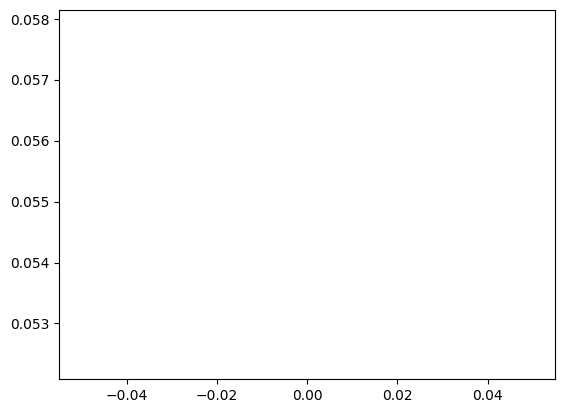

In [ ]:
plt.plot(r2_mean[r2_mean > 0.5].mean(0))

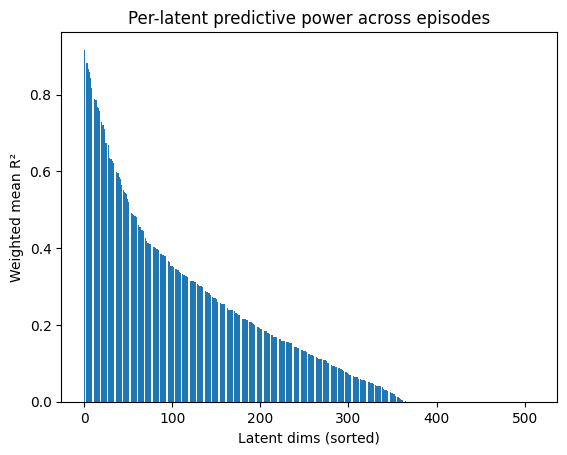

In [94]:
weights = np.var(np.concatenate(exp_vars[y_var], axis=0), axis=0)
weights = weights / np.sum(weights)
r2_weighted = (r2_mean * weights[None, :]).sum(axis=1)

order = np.argsort(r2_weighted)[::-1]
plt.bar(np.arange(len(order)), r2_weighted[order])
plt.xlabel('Latent dims (sorted)')
plt.ylabel('Weighted mean R²')
plt.title('Per-latent predictive power across episodes')
plt.show()


Coefficients shape: (5, 1)
Coefficients:
 [[-0.11169349]
 [ 0.08926811]
 [ 0.14477825]
 [ 0.17900845]
 [ 0.18838064]]

Intercept: [ 0.01613282  0.01350241  0.00259791 -0.16835204 -0.22382201]


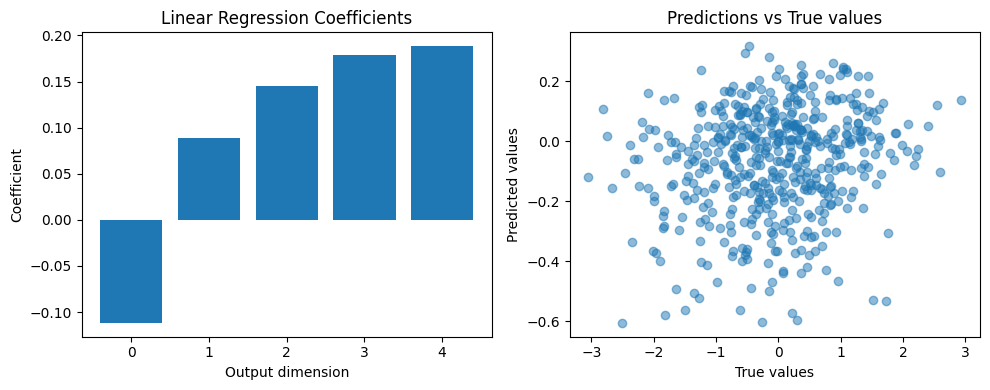

In [95]:
x = np.random.randn(100, 1)
y = np.random.randn(100, 5)

from sklearn.linear_model import LinearRegression

# Fit linear regression
reg = LinearRegression()
reg.fit(x, y)

# Show coefficients
print("Coefficients shape:", reg.coef_.shape)
print("Coefficients:\n", reg.coef_)
print("\nIntercept:", reg.intercept_)

# Visualize coefficients
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(y.shape[1]), reg.coef_.flatten())
plt.xlabel('Output dimension')
plt.ylabel('Coefficient')
plt.title('Linear Regression Coefficients')

plt.subplot(1, 2, 2)
y_pred = reg.predict(x)
plt.scatter(y, y_pred, alpha=0.5)
plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.title('Predictions vs True values')
plt.tight_layout()
plt.show()
